# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
# Not needed for this local project: dependencies are installed from requirements.txt
# into the local .venv (Python 3.14). This starter cell targeted the Udacity cloud
# workspace and an old kaggle version, so it is commented out.
# !python -m pip install kaggle==1.6.12

In [2]:
# Not needed for this local project. The original `--target=/workspace` path is the
# Udacity cloud workspace (nonexistent locally), and numpy==1.24.3 will not build on
# Python 3.14. ucimlrepo/numpy are already installed in the local .venv, so this is
# commented out.
# !pip install --target=/workspace ucimlrepo numpy==1.24.3

**Note:** Not applicable here — the two install cells above are commented out because dependencies are installed from `requirements.txt` into the local `.venv` (Python 3.14). No kernel restart is needed. *(Originally: "Restart the kernel to use updated package(s).")*

### Import libraries

All libraries used throughout the notebook are imported here, at the top. The standard-library modules (`os`, `io`, `time`, `xml.etree.ElementTree`) need no installation; `pandas` and `requests` are installed from `requirements.txt`.

In [9]:
# Import the libraries used throughout this notebook.
# Standard library (no installation needed):
import os
import io
import time
import xml.etree.ElementTree as ET

# Third-party (installed from requirements.txt):
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Render matplotlib/seaborn figures inline in the notebook.
%matplotlib inline

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

In the Udacity Master's Degree in AI, I would like to investigate the possibility of using AI to predict the infrared spectral lines of complex aromatic molecules, so that they can be used to identify them in observations from space telescopes. To prepare for this work, I would like to familiarize myself with some of the world's molecular datasets, in this project's case: the NASA Ames PAH IR Spectroscopic Database on the one hand, and PubChem on the other. I would like to try to connect them if that is at all possible. For the sake of this Data Wrangling project, the research question could be:  

*How does the number of distinct infrared emission lines vary with an aromatic molecule's size (molecular weight or carbon count), and do neutral and ionized aromatics differ in this respect?*

For this project, the two datasets are sourced from the following:

* **NASA Ames PAH IR Spectroscopic Database (PAHdb)** — infrared spectra of polycyclic aromatic hydrocarbons (theoretical library): https://www.astrochemistry.org/pahdb/
* **PubChem** — chemical structure and molecular properties, from the NCBI/NIH database: https://pubchem.ncbi.nlm.nih.gov/ (programmatic access via PUG REST: https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest)

*The starter notebook originally suggested these general dataset directories: [Google Dataset Search](https://datasetsearch.research.google.com/), [data.gov](https://data.gov/), and the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php).*

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1: NASA Ames PAH IR Spectroscopic Database (PAHdb)**

Type: **XML file** (the complete *Theoretical* library, version 4.00).

Method: **Manual download ("Downloading files").** PAHdb distributes its libraries through an email-gated web form ([download page](https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view)) — you select a library, choose *Download as XML*, provide an email address, and receive a link by email. Because there is no public static URL to download from, a manual download is the appropriate gathering method. The delivered file was saved to `data/raw/pahdb-complete-theoretical-v4.00.xml` (≈480 MB, 10,749 species). The code below programmatically loads and parses that XML into a DataFrame.

I picked PAHdb because it is the world's foremost collection of infrared (IR) spectra of polycyclic aromatic hydrocarbons (PAHs), which is exactly the spectral information needed for the research question, and it provides the ionization state that lets us compare neutral versus ionized molecules.

Dataset variables (per molecule):

*   **uid**: unique PAHdb identifier for each computed species.
*   **formula**: molecular formula (e.g., `C6H6O`) — the elemental composition, and the source of the carbon count used as a size measure.
*   **charge**: ionization state (`0` = neutral, `1`/`2`/`3` = cations, `-1` = anion) — used to compare neutral vs. ionized aromatics.
*   **weight**: molecular weight (g/mol) — a measure of molecular size.
*   **symmetry**: point-group symmetry label of the molecule.
*   **method**: the quantum-chemistry method used for the computation (e.g., `RB3LYP`).
*   **frequencies** / **intensities**: the IR emission lines. Each molecule has many vibrational modes, so these are stored as multiple values per cell (a deliberate tidiness issue to resolve later). The **number of distinct emission lines** (the count of modes) is the key variable for the research question.

There are 10,749 species (well over the 500-sample minimum) and many variables per species.

In [3]:
# --- Dataset 1: NASA Ames PAHdb (manual download, XML) ---
# The complete Theoretical library v4.00 was downloaded manually as XML (email-gated)
# from https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view and saved
# to data/raw/. Here we stream-parse that XML into one row per molecule.
# (Libraries os, xml.etree.ElementTree as ET, pandas as pd are imported at the top.)

RAW_DIR = os.path.join("data", "raw")
PAHDB_XML = os.path.join(RAW_DIR, "pahdb-complete-theoretical-v4.00.xml")
PAHDB_EXTRACT = os.path.join(RAW_DIR, "pahdb_theoretical_extracted.csv")

# The PAHdb XML uses a default namespace, so element names are prefixed with it.
NS = "{http://www.astrochemistry.org/pahdb/theoretical}"


def parse_pahdb(xml_path):
    """Stream-parse the ~480 MB PAHdb XML into one row per molecule.

    iterparse + elem.clear() keeps memory low. The vibrational modes (the IR
    emission lines) are kept as ';'-joined strings so each molecule stays on a
    single row; this intentionally leaves multiple values in one cell, which is
    tidied later with an explode.
    """
    records = []
    for _, elem in ET.iterparse(xml_path, events=("end",)):
        if elem.tag.split("}", 1)[-1] != "specie":
            continue
        # Collect the frequency/intensity of every vibrational mode.
        freqs, intens = [], []
        transitions = elem.find(f"{NS}transitions")
        if transitions is not None:
            for mode in transitions.findall(f"{NS}mode"):
                freq = mode.find(f"{NS}frequency")
                inten = mode.find(f"{NS}intensity")
                if freq is not None and inten is not None:
                    freqs.append(freq.text)
                    intens.append(inten.text)

        def get(name):
            child = elem.find(f"{NS}{name}")
            return child.text if child is not None else None

        records.append({
            "uid": elem.get("uid"),
            "formula": get("formula"),
            "charge": get("charge"),
            "weight": get("weight"),
            "symmetry": get("symmetry"),
            "method": get("method"),
            "frequencies": ";".join(freqs),
            "intensities": ";".join(intens),
        })
        elem.clear()  # release the parsed subtree to keep memory low
    return pd.DataFrame(records)


# Parse the XML once, then cache a compact extract for fast re-runs.
if os.path.exists(PAHDB_EXTRACT):
    df_pahdb = pd.read_csv(PAHDB_EXTRACT, dtype=str)
    print(f"Loaded cached extract: {PAHDB_EXTRACT}")
elif os.path.exists(PAHDB_XML):
    df_pahdb = parse_pahdb(PAHDB_XML)
    df_pahdb.to_csv(PAHDB_EXTRACT, index=False)
    print(f"Parsed {PAHDB_XML} -> cached to {PAHDB_EXTRACT}")
else:
    raise FileNotFoundError(
        "PAHdb XML not found. Download the complete Theoretical library v4.00 as XML "
        "from https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view "
        f"(email-gated) and save it to {PAHDB_XML}."
    )

print(f"df_pahdb shape: {df_pahdb.shape}")
df_pahdb.head()

Loaded cached extract: data\raw\pahdb_theoretical_extracted.csv
df_pahdb shape: (10749, 8)


,uid,formula,charge,weight,symmetry,method,frequencies,intensities
0,430,C6H6O,0,94.04186000,1-A',RB3LYP,68.22150000;266.11240000;438.55110000;445.6087...,6.57630000;0.00280000;0.00300000;8.90640000;11...
1,428,C6H6O,0,94.04186000,1-A',RB3LYP,228.83890000;351.24410000;398.38840000;413.898...,0.63210000;123.24690000;9.97170000;0.16920000;...
2,431,C6H6O+,1,94.04186000,2-A,UB3LYP,112.16990000;245.00450000;400.63220000;423.474...,7.54030000;4.52050000;2.94200000;15.97010000;2...
3,429,C6H6O+,1,94.04186000,"2-A""",UB3LYP,183.67720000;356.11560000;405.28100000;429.512...,1.12900000;3.23460000;10.24320000;0.47810000;0...
4,432,C6H7O+,1,95.04968500,1-A',RB3LYP,136.62370000;261.89450000;411.13890000;432.735...,4.28700000;5.87670000;7.88840000;0.58710000;42...


#### **Dataset 2: PubChem (PUG REST API)**

Type: **JSON/CSV via a REST API.**

Method: **Programmatic API access.** The data is gathered programmatically from the [PubChem PUG REST API](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest) (NCBI/NIH). We run a *substructure search* for the naphthalene core (the smallest polycyclic aromatic hydrocarbon), which returns the PubChem Compound IDs (CIDs) of molecules that contain that fused-ring system, and then bulk-fetch their molecular properties as CSV. This is a different gathering method from Dataset 1 (a manual file download), and the raw result is cached to `data/raw/pubchem_pah_raw.csv`.

I picked PubChem because it is a comprehensive, authoritative source of molecular structure and properties, and its API lets us programmatically pull a large set of aromatic molecules with the size descriptors (molecular weight, heavy-atom count) needed to relate structure to the PAHdb spectra.

Dataset variables (per compound):

*   **CID**: PubChem Compound identifier.
*   **MolecularFormula**: elemental composition (e.g., `C10H8`) — used later as the key to join with the PAHdb data.
*   **MolecularWeight**: molecular weight (g/mol) — a measure of molecular size.
*   **IUPACName**: systematic chemical name.
*   **SMILES**: line-notation structure string; its length is an alternative size/complexity proxy.
*   **InChIKey**: hashed structure identifier.
*   **HeavyAtomCount**: number of non-hydrogen atoms — another size measure.
*   **XLogP**: computed hydrophobicity (this column contains some missing values — a quality issue to assess later).
*   **Charge**: net charge of the compound.

The search returns well over the 500-sample minimum, each with multiple variables.

In [4]:
# --- Dataset 2: PubChem (programmatic API via PUG REST) ---
# Gathered programmatically from the PubChem PUG REST API: a substructure search for a
# polycyclic aromatic core (naphthalene) collects PAH-like compounds, then their
# molecular properties are bulk-fetched as CSV. The result is cached to data/raw/.
# (Libraries os, io, time, requests, pandas as pd are imported at the top.)

RAW_DIR = os.path.join("data", "raw")
PUBCHEM_RAW = os.path.join(RAW_DIR, "pubchem_pah_raw.csv")
PUBCHEM_BASE = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

# Naphthalene SMILES: the smallest polycyclic aromatic hydrocarbon core. A substructure
# search returns compounds that contain this fused two-ring system.
PAH_CORE_SMILES = "c1ccc2ccccc2c1"
PROPERTIES = "MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge"


def fetch_pubchem_pahs(max_records=700, chunk_size=200):
    """Query PubChem PUG REST for PAH-like compounds and their properties.

    Step 1: substructure search (naphthalene core) -> list of CIDs.
    Step 2: POST the CIDs in chunks to the property-table endpoint -> CSV.
    A short pause between requests respects PubChem's <=5 requests/sec policy.
    """
    # Step 1: substructure search returns the CIDs of matching compounds.
    search_url = f"{PUBCHEM_BASE}/compound/fastsubstructure/smiles/{PAH_CORE_SMILES}/cids/JSON"
    resp = requests.get(search_url, params={"MaxRecords": max_records}, timeout=120)
    resp.raise_for_status()
    cids = resp.json()["IdentifierList"]["CID"]

    # Step 2: fetch the property table for those CIDs, in chunks (POST body).
    frames = []
    for start in range(0, len(cids), chunk_size):
        chunk = cids[start:start + chunk_size]
        prop_url = f"{PUBCHEM_BASE}/compound/cid/property/{PROPERTIES}/CSV"
        r = requests.post(prop_url, data={"cid": ",".join(map(str, chunk))}, timeout=120)
        r.raise_for_status()
        frames.append(pd.read_csv(io.StringIO(r.text)))
        time.sleep(0.25)  # stay well under 5 requests/sec
    return pd.concat(frames, ignore_index=True)


# Fetch once from the API, then cache for fast, reproducible re-runs.
if os.path.exists(PUBCHEM_RAW):
    df_pubchem = pd.read_csv(PUBCHEM_RAW)
    print(f"Loaded cached PubChem data: {PUBCHEM_RAW}")
else:
    df_pubchem = fetch_pubchem_pahs()
    df_pubchem.to_csv(PUBCHEM_RAW, index=False)
    print(f"Fetched from PubChem API -> cached to {PUBCHEM_RAW}")

print(f"df_pubchem shape: {df_pubchem.shape}")
df_pubchem.head()

Loaded cached PubChem data: data\raw\pubchem_pah_raw.csv
df_pubchem shape: (700, 9)


,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge
0,931,C10H8,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,3.3,0
1,6129,C12H11NO2,201.22,naphthalen-1-yl N-methylcarbamate,CNC(=O)OC1=CC=CC2=CC=CC=C21,CVXBEEMKQHEXEN-UHFFFAOYSA-N,15,2.4,0
2,2336,C20H12,252.30,benzo[a]pyrene,C1=CC=C2C3=C4C(=CC2=C1)C=CC5=C4C(=CC=C5)C=C3,FMMWHPNWAFZXNH-UHFFFAOYSA-N,20,6.0,0
3,3503,C30H30O8,518.60,"7-(8-formyl-1,6,7-trihydroxy-3-methyl-5-propan...",CC1=CC2=C(C(=C(C(=C2C(C)C)O)O)C=O)C(=C1C3=C(C4...,QBKSWRVVCFFDOT-UHFFFAOYSA-N,38,6.9,0
4,8418,C14H10,178.23,anthracene,C1=CC=C2C=C3C=CC=CC3=CC2=C1,MWPLVEDNUUSJAV-UHFFFAOYSA-N,14,4.4,0


**Store the raw data.** The two gathering cells above already save their raw output to the local data store (`data/raw/`): the manually downloaded PAHdb XML, the parsed PAHdb extract, and the PubChem API response. The cell below confirms those raw files are present before we move on to assessing and cleaning.

In [5]:
# Confirm the raw data files are stored in the local data store (data/raw/).
# The gathering cells wrote these; here we simply list them with their sizes.
for name in [
    "pahdb-complete-theoretical-v4.00.xml",  # Dataset 1: manual download (raw XML)
    "pahdb_theoretical_extracted.csv",       # Dataset 1: parsed extract
    "pubchem_pah_raw.csv",                    # Dataset 2: PubChem API response
]:
    path = os.path.join(RAW_DIR, name)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1_000_000
        print(f"OK   {path}  ({size_mb:.2f} MB)")
    else:
        print(f"MISSING  {path}")

OK   data\raw\pahdb-complete-theoretical-v4.00.xml  (503.34 MB)
OK   data\raw\pahdb_theoretical_extracted.csv  (62.79 MB)
OK   data\raw\pubchem_pah_raw.csv  (0.13 MB)


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Missing values in the PubChem `XLogP` column (completeness)

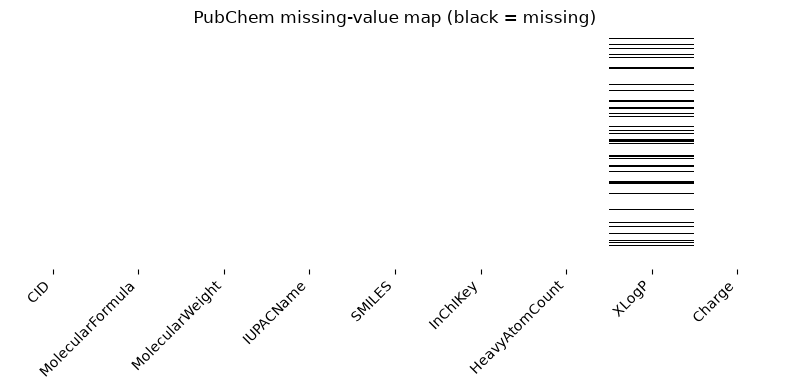

,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge
21,5282412,C43H47N2NaO6S2,775.00,"sodium 4-[(2Z)-2-[(2E,4E,6E)-7-[1,1-dimethyl-3...",CC1(C(=[N+](C2=C1C3=CC=CC=C3C=C2)CCCCS(=O)(=O)...,MOFVSTNWEDAEEK-UHFFFAOYSA-M,54,NaN,0
38,11079,C14H15ClN2,246.73,"2-(naphthalen-1-ylmethyl)-4,5-dihydro-1H-imida...",C1CN=C(N1)CC2=CC=CC3=CC=CC=C32.Cl,DJDFFEBSKJCGHC-UHFFFAOYSA-N,17,NaN,0
39,62882,C16H22ClNO2,295.80,1-naphthalen-1-yloxy-3-(propan-2-ylamino)propa...,CC(C)NCC(COC1=CC=CC2=CC=CC=C21)O.Cl,ZMRUPTIKESYGQW-UHFFFAOYSA-N,20,NaN,0
50,5281033,C34H30N2O6S,594.70,4-[(3-carboxy-2-hydroxynaphthalen-1-yl)methyl]...,CN1CCCN=C1/C=C/C2=CC=CS2.C1=CC=C2C(=C1)C=C(C(=...,AQXXZDYPVDOQEE-MXDQRGINSA-N,43,NaN,0
68,60834,C18H20ClNOS,333.90,(3S)-N-methyl-3-naphthalen-1-yloxy-3-thiophen-...,CNCC[C@@H](C1=CC=CS1)OC2=CC=CC3=CC=CC=C32.Cl,BFFSMCNJSOPUAY-LMOVPXPDSA-N,22,NaN,0
69,23681059,C14H13NaO3,252.24,sodium (2S)-2-(6-methoxynaphthalen-2-yl)propan...,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)[O-].[Na+],CDBRNDSHEYLDJV-FVGYRXGTSA-M,18,NaN,0
76,312915,C26H35NO7,473.60,2-(diethylamino)ethyl 2-(naphthalen-1-ylmethyl...,CCN(CC)CCOC(=O)C(CC1CCCO1)CC2=CC=CC3=CC=CC=C32...,SSAJNPNVUYMUCI-UHFFFAOYSA-N,34,NaN,0
104,156418,C22H23ClF3N,393.90,N-[(1R)-1-naphthalen-1-ylethyl]-3-[3-(trifluor...,C[C@H](C1=CC=CC2=CC=CC=C21)NCCCC3=CC(=CC=C3)C(...,QANQWUQOEJZMLL-PKLMIRHRSA-N,27,NaN,0
106,23667630,C21H21N2NaO5S,436.50,"sodium (2S,5R,6R)-6-[(2-ethoxynaphthalene-1-ca...",CCOC1=C(C2=CC=CC=C2C=C1)C(=O)N[C@H]3[C@@H]4N(C...,AYAPZOUDXCDGIF-FRFVDRIFSA-M,30,NaN,0
109,8514,C51H34N6Na6O23S6,1429.20,hexasodium;8-[[4-methyl-3-[[3-[[3-[[2-methyl-5...,CC1=C(C=C(C=C1)C(=O)NC2=C3C(=CC(=CC3=C(C=C2)S(...,VAPNKLKDKUDFHK-UHFFFAOYSA-H,92,NaN,0


In [10]:
# Visual inspection: a missingness heatmap gives a one-shot overview of where values are
# missing across the whole PubChem dataframe (similar to missingno's matrix plot). Each
# row is a compound and each column a variable; missing cells show as black bands. XLogP
# is the one column with visible gaps.
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_pubchem.isna(), cbar=False, cmap="Greys", yticklabels=False, ax=ax)
ax.set_title("PubChem missing-value map (black = missing)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# A closer look at the specific rows where XLogP is missing:
df_pubchem[df_pubchem["XLogP"].isna()].head(10)

In [7]:
# Programmatic inspection: count the missing values per column, then report the exact
# count and percentage for XLogP.
print("Missing values per column:")
print(df_pubchem.isna().sum())

n_missing = df_pubchem["XLogP"].isna().sum()
print(
    f"\nXLogP missing: {n_missing} of {len(df_pubchem)} "
    f"({df_pubchem['XLogP'].isna().mean() * 100:.1f}%)"
)

Missing values per column:
CID                  0
MolecularFormula     0
MolecularWeight      0
IUPACName            1
SMILES               0
InChIKey             0
HeavyAtomCount       0
XLogP               93
Charge               0
dtype: int64

XLogP missing: 93 of 700 (13.3%)


Issue and justification: The PubChem `XLogP` column is **incomplete** — 93 of the 700 compounds (~13%) have no value (`NaN`). XLogP is a *computed* octanol–water partition coefficient that PubChem does not report for every compound, so the gaps arise at the source. This is a **completeness** data-quality problem (one of the data-quality pillars).

*Justification of methods:* the **visual** check filters the dataframe to the rows where `XLogP` is missing, making the empty/`NaN` cells directly visible; the **programmatic** check uses `isna().sum()` to count missing values per column and reports the exact count and percentage for `XLogP`, objectively confirming the scale of the gap.

### Quality Issue 2:

In [ ]:
#FILL IN - Inspecting the dataframe visually

In [ ]:
#FILL IN - Inspecting the dataframe programmatically

Issue and justification: *FILL IN*

### Tidiness Issue 1:

In [ ]:
#FILL IN - Inspecting the dataframe visually

In [ ]:
#FILL IN - Inspecting the dataframe programmatically

Issue and justification: *FILL IN*

### Tidiness Issue 2: 

In [ ]:
#FILL IN - Inspecting the dataframe visually

In [ ]:
#FILL IN - Inspecting the dataframe programmatically

Issue and justification: *FILL IN*

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [ ]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted

### **Quality Issue 1: FILL IN**

In [ ]:
# FILL IN - Apply the cleaning strategy

In [ ]:
# FILL IN - Validate the cleaning was successful

Justification: *FILL IN*

### **Quality Issue 2: FILL IN**

In [ ]:
#FILL IN - Apply the cleaning strategy

In [ ]:
#FILL IN - Validate the cleaning was successful

Justification: *FILL IN*

### **Tidiness Issue 1: FILL IN**

In [ ]:
#FILL IN - Apply the cleaning strategy

In [ ]:
#FILL IN - Validate the cleaning was successful

Justification: *FILL IN*

### **Tidiness Issue 2: FILL IN**

In [ ]:
#FILL IN - Apply the cleaning strategy

In [ ]:
#FILL IN - Validate the cleaning was successful

Justification: *FILL IN*

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [ ]:
#FILL IN - Remove unnecessary variables and combine datasets

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [ ]:
#FILL IN - saving data

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* FILL IN from answer to Step 1

In [ ]:
#Visual 1 - FILL IN

*Answer to research question:* FILL IN

In [ ]:
#Visual 2 - FILL IN

*Answer to research question:* FILL IN

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* FILL IN